In [1]:
!pip install -q newspaper3k nltk scikit-learn vaderSentiment transformers torch lxml_html_clean

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from newspaper import Article
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM, pipeline
import torch
import numpy as np
import matplotlib.pyplot as plt
import requests

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 59.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 7.9 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

bart_tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model     = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

def bart_summarize(text, max_length=200, min_length=80):
    inputs = bart_tokenizer(
        text,
        return_tensors='pt',
        max_length=1024,
        truncation=True
    )
    ids = bart_model.generate(
        inputs['input_ids'],
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return bart_tokenizer.decode(ids[0], skip_special_tokens=True)

sent_pipe = pipeline('sentiment-analysis',
                     model='distilbert-base-uncased-finetuned-sst-2-english')
emo_pipe  = pipeline('text-classification',
                     model='j-hartmann/emotion-english-distilroberta-base',
                     top_k=None)
sbert_tok = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
sbert_mod = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

print("All models loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All models loaded.


In [6]:
import requests
from newspaper import Article

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

# Article 1: CFR — mainstream/liberal-leaning on climate change
# Article 2: Heartland Institute — conservative/skeptic-leaning on climate change
# Both are publicly accessible, no paywall — same political contrast as NYT vs Fox
url1 = 'https://www.cfr.org/article/earth-experienced-another-year-record-warming-climate-fallout-was-intense'
url2 = 'https://heartland.org/opinion/ipcc-and-sceptics-agree-climate-change-is-not-causing-extreme-weather/'

def scrape(url, label):
    response = requests.get(url, headers=headers, timeout=15)
    art = Article(url)
    art.set_html(response.text)
    art.parse()
    art.nlp()
    print(f"=== {label} ===")
    print(f"Status : {response.status_code}")
    print(f"Title  : {art.title}")
    print(f"Words  : {len(art.text.split())}\n")
    return art

art1 = scrape(url1, 'CFR (Mainstream)')
art2 = scrape(url2, 'Heartland Institute (Conservative)')
text1, text2 = art1.text, art2.text

assert len(text1.split()) > 50, "CFR article failed — check URL"
assert len(text2.split()) > 50, "Heartland article failed — check URL"
print("Both articles loaded successfully.")

=== CFR (Mainstream) ===
Status : 200
Title  : The Earth Experienced Another Year of Record Warming. The Climate Fallout Was Intense
Words  : 168

=== Heartland Institute (Conservative) ===
Status : 200
Title  : IPCC and Sceptics Agree: Climate Change Is Not Causing Extreme Weather
Words  : 2322

Both articles loaded successfully.


## 1. Based on AI/ML methods, measure the similarity between the two articles.

In [7]:
# --- TF-IDF Cosine ---
tfidf        = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform([text1, text2])
cosine_tfidf = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

# --- Sentence-BERT ---
def mean_pooling(output, mask):
    tokens   = output[0]
    mask_exp = mask.unsqueeze(-1).expand(tokens.size()).float()
    return torch.sum(tokens * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)

def get_embedding(text):
    trunc = ' '.join(text.split()[:500])
    enc   = sbert_tok(trunc, padding=True, truncation=True, max_length=512, return_tensors='pt')
    with torch.no_grad():
        out = sbert_mod(**enc)
    emb = mean_pooling(out, enc['attention_mask'])
    return torch.nn.functional.normalize(emb, p=2, dim=1)

emb1, emb2 = get_embedding(text1), get_embedding(text2)
sbert_sim   = torch.nn.functional.cosine_similarity(emb1, emb2).item()
print(f"  TF-IDF Cosine  : {cosine_tfidf:.4f}  (lexical overlap)")
print(f"  Sentence-BERT  : {sbert_sim:.4f}  (semantic similarity)")
print("\nIf SBERT > TF-IDF: same ideas, different vocabulary — typical across politically divergent outlets.")

  TF-IDF Cosine  : 0.2347  (lexical overlap)
  Sentence-BERT  : 0.5552  (semantic similarity)

If SBERT > TF-IDF: same ideas, different vocabulary — typical across politically divergent outlets.


## 2. Do they share   
a. Similar topics,  


In [18]:
def top_keywords(text, n=5):
    vec = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))
    X   = vec.fit_transform([text])
    sc  = X.toarray()[0]
    idx = sc.argsort()[::-1][:n]
    return [(vec.get_feature_names_out()[i], round(sc[i], 4)) for i in idx]

kw1 = top_keywords(text1)
kw2 = top_keywords(text2)

print("\nCFR:")
for k, s in kw1: print(f"  {k:35s} {s}")
print("\nHeartland:")
for k, s in kw2: print(f"  {k:35s} {s}")

# LDA
cv  = CountVectorizer(stop_words='english', max_features=500)
dtm = cv.fit_transform([text1, text2])
lda = LatentDirichletAllocation(n_components=2, random_state=42).fit(dtm)
fn  = cv.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top = [fn[j] for j in topic.argsort()[:-11:-1]]
    print(f"  Topic {i+1}: {' | '.join(top)}")


CFR:
  world                               0.2545
  climate                             0.2545
  emissions                           0.2545
  warming                             0.1909
  work                                0.1273

Heartland:
  climate                             0.5587
  change                              0.2123
  climate change                      0.19
  ipcc                                0.1564
  surface                             0.1453
  Topic 1: emissions | avert | levels | sivaram | greenhouse | coming | continue | needs | end | cumulative
  Topic 2: climate | change | ipcc | surface | states | clouds | alexander | crisis | weather | frequency


b. Sentiment, and

In [10]:
sia = SentimentIntensityAnalyzer()

def vader_article(text, label):
    sents = nltk.sent_tokenize(text)
    sc    = [sia.polarity_scores(s) for s in sents]
    avg   = sum(s['compound'] for s in sc) / len(sc)
    lbl   = 'Positive' if avg >= 0.05 else ('Negative' if avg <= -0.05 else 'Neutral')
    print(f"  VADER — {label}: {avg:.4f}  =>  {lbl}")
    return sc, avg

def transformer_sent(text, label):
    trunc = ' '.join(text.split()[:300])
    r     = sent_pipe(trunc, truncation=True, max_length=512)[0]
    print(f"  DistilBERT — {label}: {r['label']} ({r['score']:.4f})")
    return r

scores1, comp1 = vader_article(text1, 'CFR')
scores2, comp2 = vader_article(text2, 'Heartland')
print()
sent1 = transformer_sent(text1, 'CFR')
sent2 = transformer_sent(text2, 'Heartland')

  VADER — CFR: -0.1299  =>  Negative
  VADER — Heartland: -0.0662  =>  Negative

  DistilBERT — CFR: NEGATIVE (0.9683)
  DistilBERT — Heartland: NEGATIVE (0.9794)


c. Emotions?

In [15]:
def get_emotions(text, label):
    sample  = ' '.join(text.split()[:300])
    results = sorted(
        emo_pipe(sample, truncation=True, max_length=512)[0],
        key=lambda x: x['score'], reverse=True
    )
    print(f"=== {label} ===")
    for e in results:
        print(f"  {e['label']:15s}: {e['score']:.4f}")
    print(f"  => Dominant: {results[0]['label'].upper()}\n")
    return results

emo1 = get_emotions(text1, 'CFR')
emo2 = get_emotions(text2, 'Heartland')

=== CFR ===
  neutral        : 0.5577
  fear           : 0.3440
  sadness        : 0.0321
  disgust        : 0.0316
  anger          : 0.0245
  surprise       : 0.0064
  joy            : 0.0036
  => Dominant: NEUTRAL

=== Heartland ===
  neutral        : 0.7743
  fear           : 0.1294
  surprise       : 0.0357
  disgust        : 0.0236
  anger          : 0.0194
  sadness        : 0.0113
  joy            : 0.0063
  => Dominant: NEUTRAL



## 3. Identify the top five keywords in each article.

In [11]:
print("\nCFR (Mainstream):")
for k, s in kw1: print(f"  {k}")
print("\nHeartland (Conservative):")
for k, s in kw2: print(f"  {k}")


CFR (Mainstream):
  world
  climate
  emissions
  warming
  work

Heartland (Conservative):
  climate
  change
  climate change
  ipcc
  surface


## 4. Summarize your findings using LLMs.

In [16]:
findings_text = (
    f"Two articles on climate change and extreme weather were compared. "
    f"Article 1 from CFR titled '{art1.title}' represents mainstream climate science coverage. "
    f"Article 2 from Heartland Institute titled '{art2.title}' represents a conservative skeptical view. "
    f"TF-IDF similarity was {cosine_tfidf:.2f} and Sentence-BERT similarity was {sbert_sim:.2f}. "
    f"CFR top keywords: {[k[0] for k in kw1]}. Heartland top keywords: {[k[0] for k in kw2]}. "
    f"CFR VADER sentiment: {comp1:.2f}, Heartland VADER sentiment: {comp2:.2f}. "
    f"CFR transformer sentiment: {sent1['label']}, Heartland: {sent2['label']}. "
    f"CFR dominant emotion: {emo1[0]['label']}, Heartland dominant emotion: {emo2[0]['label']}."
)

summary = bart_summarize(findings_text, max_length=200, min_length=80)
print(summary)

Two articles on climate change and extreme weather were compared. Article 1 from CFR titled 'The Earth Experienced Another Year of Record Warming. The Climate Fallout Was Intense' represents mainstream climate science coverage. Article 2 from Heartland Institute titled 'IPCC and Sceptics Agree: Climate Change Is Not Causing Extreme Weather' represents a conservative skeptical view. TF-IDF similarity was 0.23 and Sentence-BERT similarity was0.56.


## Visualizations

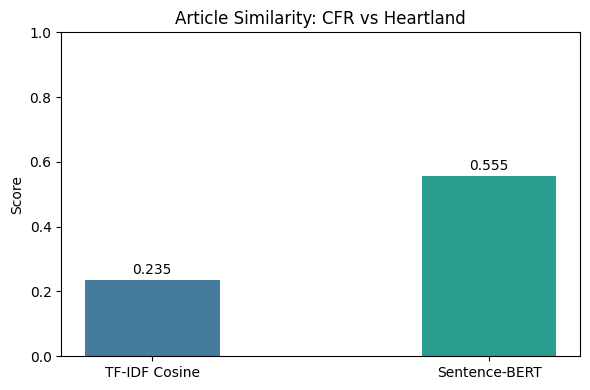

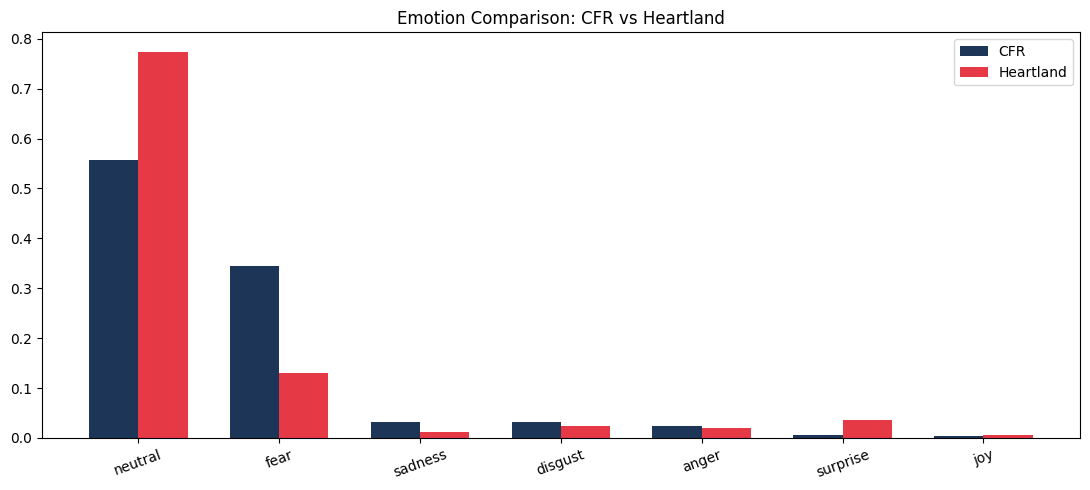

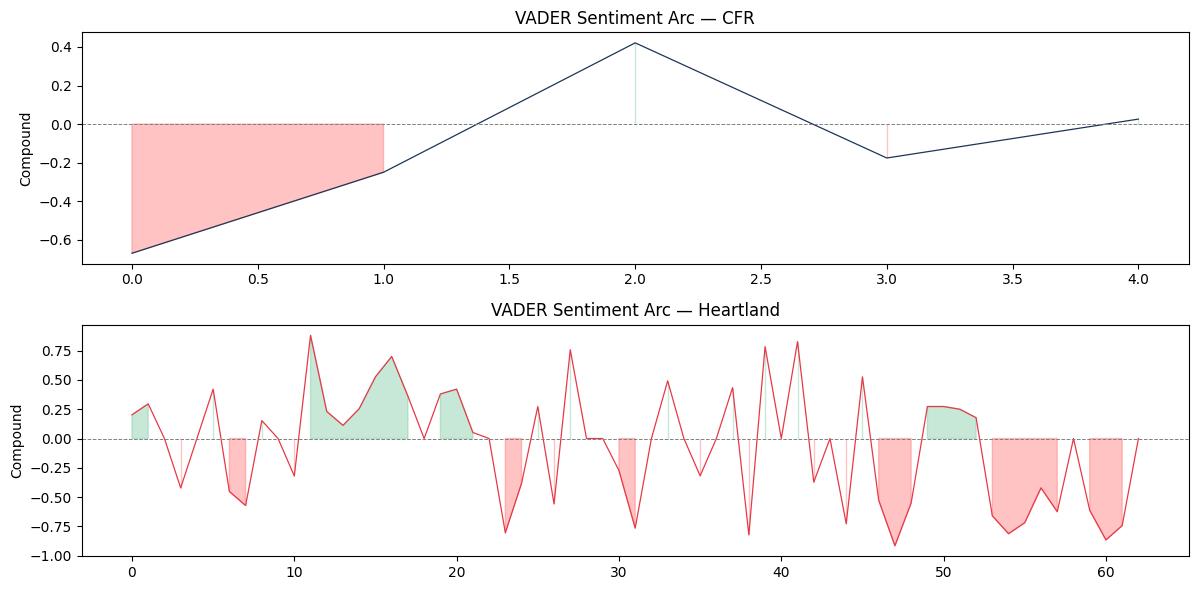

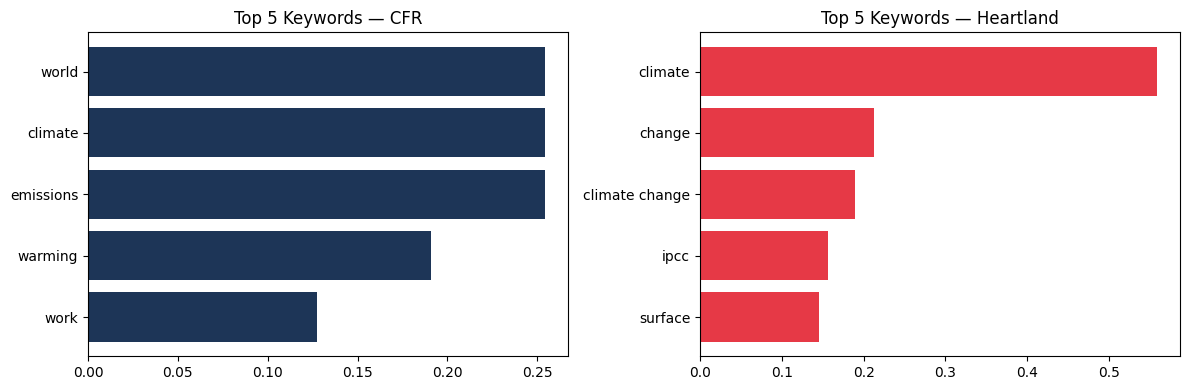

In [17]:
# Chart 1: Similarity Scores
plt.figure(figsize=(6, 4))
bars = plt.bar(['TF-IDF Cosine', 'Sentence-BERT'], [cosine_tfidf, sbert_sim],
               color=['#457b9d', '#2a9d8f'], width=0.4)
plt.ylim(0, 1); plt.ylabel('Score')
plt.title('Article Similarity: CFR vs Heartland')
for bar, val in zip(bars, [cosine_tfidf, sbert_sim]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center')
plt.tight_layout(); plt.savefig('hw8_similarity.png', dpi=150); plt.show()

# Chart 2: Emotion Comparison
emo_labels = [e['label'] for e in emo1]
sc_cfr     = [e['score'] for e in emo1]
sc_heart   = [next(e['score'] for e in emo2 if e['label'] == l) for l in emo_labels]
x = np.arange(len(emo_labels))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.175, sc_cfr,   0.35, label='CFR',       color='#1d3557')
ax.bar(x + 0.175, sc_heart, 0.35, label='Heartland', color='#e63946')
ax.set_xticks(x); ax.set_xticklabels(emo_labels, rotation=20)
ax.set_title('Emotion Comparison: CFR vs Heartland'); ax.legend()
plt.tight_layout(); plt.savefig('hw8_emotions.png', dpi=150); plt.show()

# Chart 3: VADER Sentiment Arcs
c1 = [s['compound'] for s in scores1]
c2 = [s['compound'] for s in scores2]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
for ax, c, label, col in [(ax1, c1, 'CFR', '#1d3557'), (ax2, c2, 'Heartland', '#e63946')]:
    ax.plot(c, color=col, linewidth=0.9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.fill_between(range(len(c)), c, 0, where=[v > 0 for v in c], color='#74c69d', alpha=0.4)
    ax.fill_between(range(len(c)), c, 0, where=[v < 0 for v in c], color='#ff6b6b', alpha=0.4)
    ax.set_title(f'VADER Sentiment Arc — {label}'); ax.set_ylabel('Compound')
plt.tight_layout(); plt.savefig('hw8_sentiment_arcs.png', dpi=150); plt.show()

# Chart 4: Keywords Side-by-Side
kw1_w, kw1_s = zip(*kw1); kw2_w, kw2_s = zip(*kw2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh(kw1_w[::-1], kw1_s[::-1], color='#1d3557'); ax1.set_title('Top 5 Keywords — CFR')
ax2.barh(kw2_w[::-1], kw2_s[::-1], color='#e63946'); ax2.set_title('Top 5 Keywords — Heartland')
plt.tight_layout(); plt.savefig('hw8_keywords.png', dpi=150); plt.show()